## Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np



## To use GPU accelaration

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Load CIFAR-10 Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)

# Example shape
example_data, _ = next(iter(train_loader))
print("Image shape:", example_data[0].shape)  # (3, 32, 32)


100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


Image shape: torch.Size([3, 32, 32])


##  Define the Normal Autoencoder for CIFAR-10

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3*32*32),
            nn.Sigmoid(),
            nn.Unflatten(1, (3, 32, 32))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

autoencoder = Autoencoder()


## Define the Denoising Autoencoder for CIFAR-10

In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3*32*32),
            nn.Sigmoid(),
            nn.Unflatten(1, (3, 32, 32))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

denoising_ae = DenoisingAutoencoder()


## Training Both Autoencoders

In [6]:
autoencoder.to(device)
denoising_ae.to(device)

def train(model, loader, noise=False, epochs=3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.to(device)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        print(f"Epoch [{epoch+1}/{epochs}]")

        for imgs, _ in loader:
            imgs = imgs.to(device)
            noisy_imgs = imgs + 0.3 * torch.randn_like(imgs).to(device) if noise else imgs
            noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)

            outputs = model(noisy_imgs)
            loss = criterion(outputs, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Avg Loss: {running_loss / len(loader):.4f}")


## Train

In [7]:
train(autoencoder, train_loader, noise=False, epochs=20)
train(denoising_ae, train_loader, noise=True, epochs=20)


Epoch [1/20]
Avg Loss: 0.0267
Epoch [2/20]
Avg Loss: 0.0157
Epoch [3/20]
Avg Loss: 0.0132
Epoch [4/20]
Avg Loss: 0.0118
Epoch [5/20]
Avg Loss: 0.0110
Epoch [6/20]
Avg Loss: 0.0103
Epoch [7/20]
Avg Loss: 0.0118
Epoch [8/20]
Avg Loss: 0.0099
Epoch [9/20]
Avg Loss: 0.0095
Epoch [10/20]
Avg Loss: 0.0093
Epoch [11/20]
Avg Loss: 0.0090
Epoch [12/20]
Avg Loss: 0.0089
Epoch [13/20]
Avg Loss: 0.0087
Epoch [14/20]
Avg Loss: 0.0086
Epoch [15/20]
Avg Loss: 0.0085
Epoch [16/20]
Avg Loss: 0.0084
Epoch [17/20]
Avg Loss: 0.0083
Epoch [18/20]
Avg Loss: 0.0082
Epoch [19/20]
Avg Loss: 0.0087
Epoch [20/20]
Avg Loss: 0.0081
Epoch [1/20]
Avg Loss: 0.0299
Epoch [2/20]
Avg Loss: 0.0183
Epoch [3/20]
Avg Loss: 0.0159
Epoch [4/20]
Avg Loss: 0.0145
Epoch [5/20]
Avg Loss: 0.0136
Epoch [6/20]
Avg Loss: 0.0131
Epoch [7/20]
Avg Loss: 0.0125
Epoch [8/20]
Avg Loss: 0.0122
Epoch [9/20]
Avg Loss: 0.0117
Epoch [10/20]
Avg Loss: 0.0114
Epoch [11/20]
Avg Loss: 0.0113
Epoch [12/20]
Avg Loss: 0.0111
Epoch [13/20]
Avg Loss: 0.

## Generate Noise Vectors from N(5, 1)

In [8]:
mean = 5
std = 1
latent_dim = 128  # Must match encoder output size
num_samples = 5

noise_vectors = torch.randn((num_samples, latent_dim)) * std + mean


## Decode with Normal Autoencoder

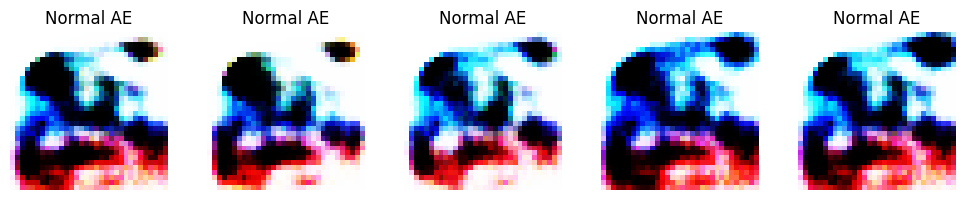

In [9]:
autoencoder.eval()

# Move noise to the same device as the model
noise_vectors_gpu = noise_vectors.to(device)

# Generate images on GPU
with torch.no_grad():
    gen_normal = autoencoder.decoder(noise_vectors_gpu)

# Move generated images to CPU for visualization
gen_normal = gen_normal.cpu()

# Plot the generated images
plt.figure(figsize=(10, 2))
for i, img in enumerate(gen_normal):
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title("Normal AE")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Decode with Denoising Autoencoder


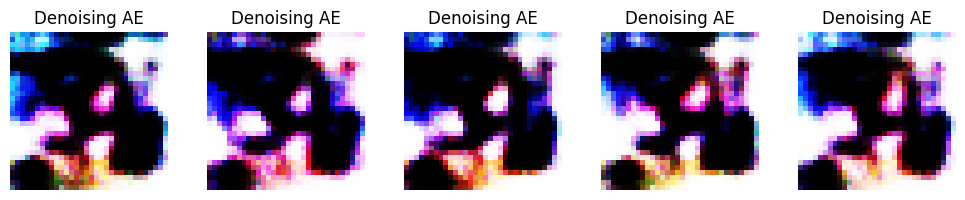

In [10]:
denoising_ae.eval()
noise_vectors_gpu = noise_vectors.to(device)

with torch.no_grad():
    gen_denoised = denoising_ae.decoder(noise_vectors_gpu)

gen_denoised = gen_denoised.cpu()

plt.figure(figsize=(10, 2))
for i, img in enumerate(gen_denoised):
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title("Denoising AE")
    plt.axis('off')
plt.tight_layout()
plt.show()
